# Data visualization with Seaborn
- lineplot
- scatterplot
- facetplot
- histogram
- countplot
- barplot
- reg plot [optional]
- pair plot
- joint plot [ optional ]
- plotly [ optional ]
-- scatter, line, histogram

# lineplot using seaborn

In [31]:
# lineplot is used to show the relationship between two variables. It is a type of plot that displays information as a series of data points called 'markers' connected by straight line segments. Lineplots are commonly used to visualize trends over time or to compare different groups.
# In a lineplot, the x-axis typically represents the independent variable (e.g., time, categories), while the y-axis represents the dependent variable (e.g., values, measurements). Each data point is plotted on the graph, and lines are drawn between the points to show the overall trend or pattern in the data.
# Lineplots are useful for identifying trends, patterns, and relationships between variables. They can also be used to compare multiple groups or categories by plotting multiple lines on the same graph, each representing a different group. This allows for easy visual comparison and analysis of the data.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


student = pd.read_csv("sns_data.csv")

In [32]:
student.head()

,student_id,class_level,subject,study_hours,test_score,week,attendance_rate,gender,hostel,Tshirt_size
0,1,Freshman,Math,5,78,1,90,Male,True,30
1,2,Freshman,Science,3,65,1,80,Female,False,20
2,3,Freshman,History,4,70,1,85,Male,True,20
3,4,Freshman,Language,2,60,1,75,Female,True,40
4,5,Sophomore,Math,6,82,1,92,Male,True,20


<Axes: xlabel='week', ylabel='attendance_rate'>

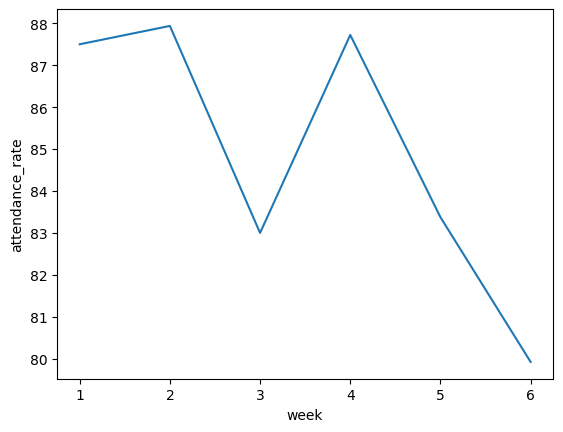

In [33]:
sns.lineplot(data=student, x="week", y = "attendance_rate", errorbar=None)

<Axes: xlabel='week', ylabel='attendance_rate'>

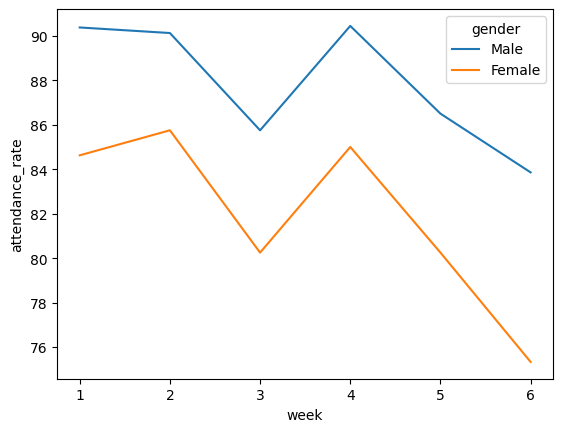

In [34]:
# axes level 
sns.lineplot(data=student, x="week", y = "attendance_rate", errorbar=None, hue="gender") # hue is used to differentiate the lines based on a categorical variable

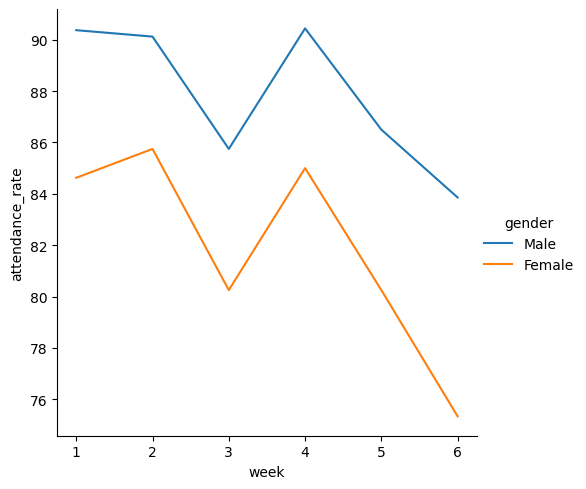

In [35]:
# figure level 
# in one figure we can plot multiple axes. and in each axes we can plot multiple lines.
sns.relplot(kind='line', data=student, x="week", y = "attendance_rate", errorbar=None, hue="gender")

# Scatter plot using seaborn

<Axes: xlabel='study_hours', ylabel='test_score'>

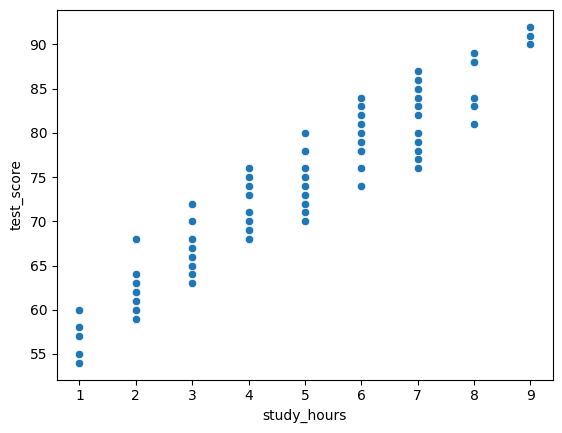

In [36]:
# used for observe correlation
sns.scatterplot(data=student, x="study_hours", y="test_score")

<Axes: xlabel='study_hours', ylabel='test_score'>

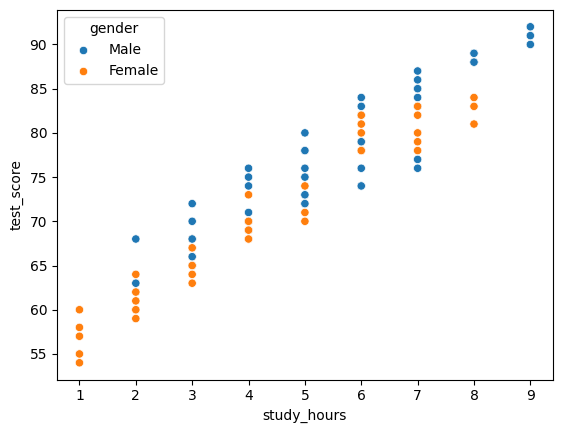

In [37]:
sns.scatterplot(data=student, x="study_hours", y="test_score", hue="gender")

<Axes: xlabel='study_hours', ylabel='test_score'>

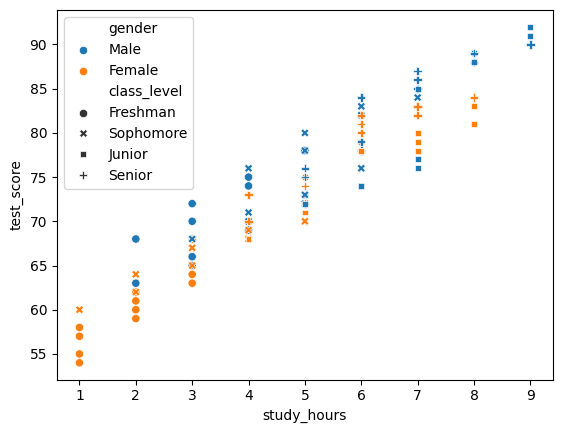

In [38]:
sns.scatterplot(data=student, x="study_hours", y="test_score", hue="gender", style="class_level")

<Axes: xlabel='study_hours', ylabel='test_score'>

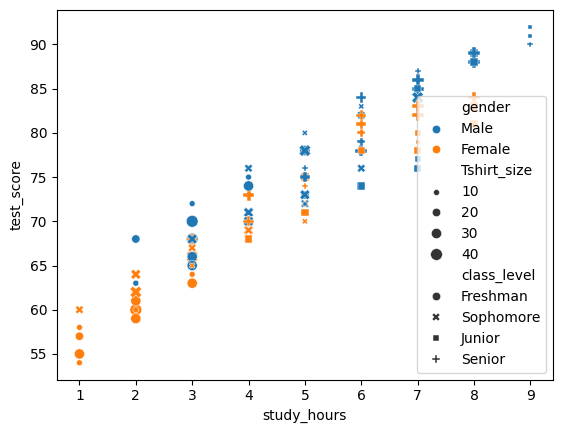

In [39]:
sns.scatterplot(data=student, x="study_hours", y="test_score", hue="gender", style="class_level", size="Tshirt_size")

In [40]:
tips_data = sns.load_dataset("tips")

In [41]:
tips_data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


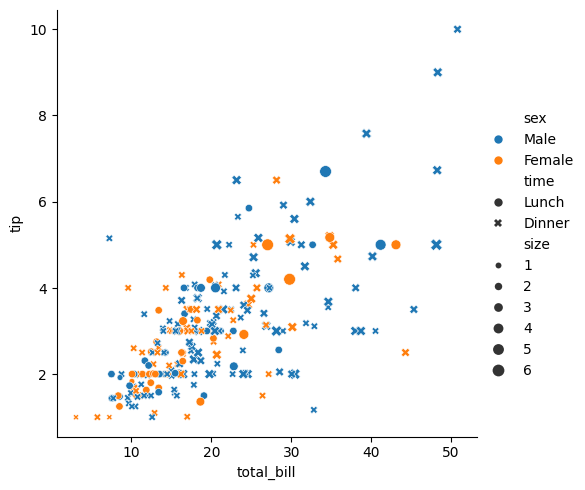

In [42]:
sns.relplot(kind='scatter',data=tips_data, x='total_bill', y='tip',hue='sex', style='time', size='size')

# facet plot

In [43]:
df = pd.read_csv("student_dataset_complete.csv")

In [44]:
df.head()

,number_courses,time_study,Marks,student_id,class_level,subject,study_hours,test_score,week,attendance_rate,gender,hostel,Tshirt_size,class_name
0,3,4.508,19.202,1,10,Science,4.508,19.202,2,0.89,F,0,2,Sophomore
1,4,0.096,7.734,2,12,Math,0.096,7.734,3,0.98,M,0,3,Senior
2,4,3.133,13.811,3,11,Science,3.133,13.811,5,0.83,F,0,3,Junior
3,6,7.909,53.018,4,10,Science,7.909,53.018,4,0.92,F,1,4,Sophomore
4,8,7.811,55.299,5,11,English,7.811,55.299,3,0.80,M,1,4,Junior


<Axes: xlabel='study_hours', ylabel='test_score'>

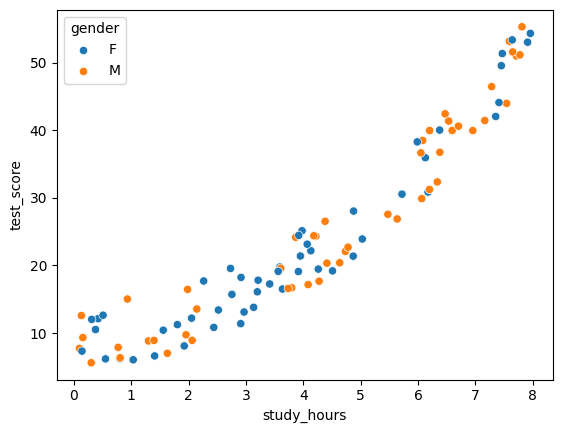

In [45]:


sns.scatterplot(data=df, x="study_hours", y="test_score", hue="gender")

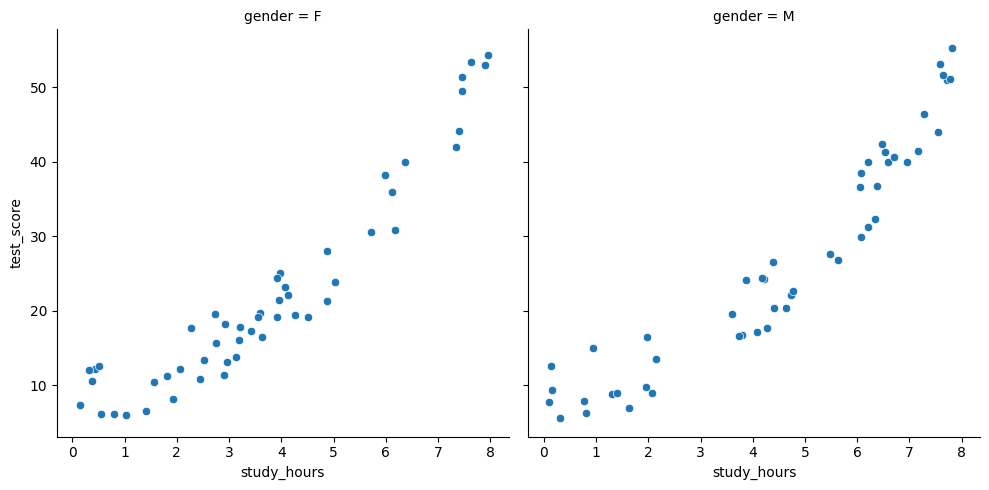

In [46]:
# facet plot 
# works in figure level

sns.relplot(kind="scatter", data=df, x="study_hours", y="test_score", col="gender")       # relplot refers figure level and scatterplot refers axes level. so we can plot multiple scatterplots in one figure using relplot. 


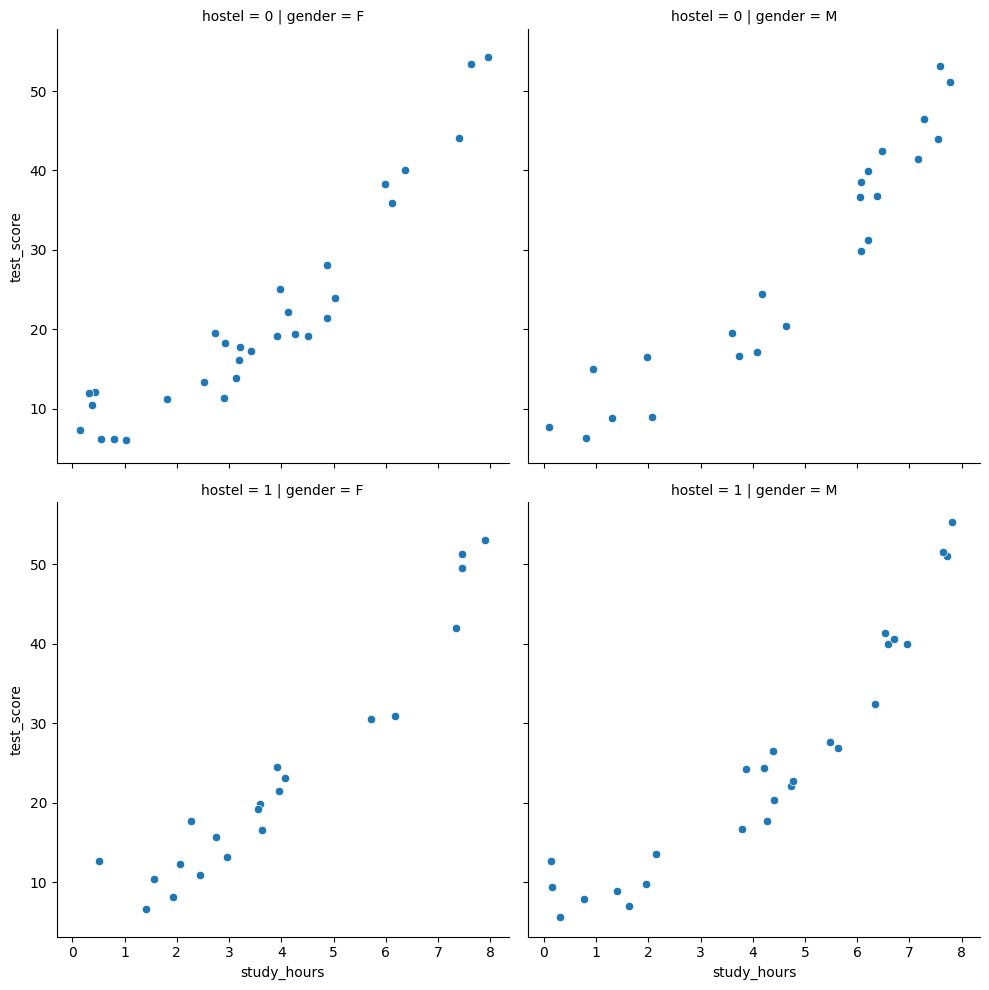

In [47]:
sns.relplot(kind="scatter", data=df, x="study_hours", y="test_score", col="gender", row="hostel") 

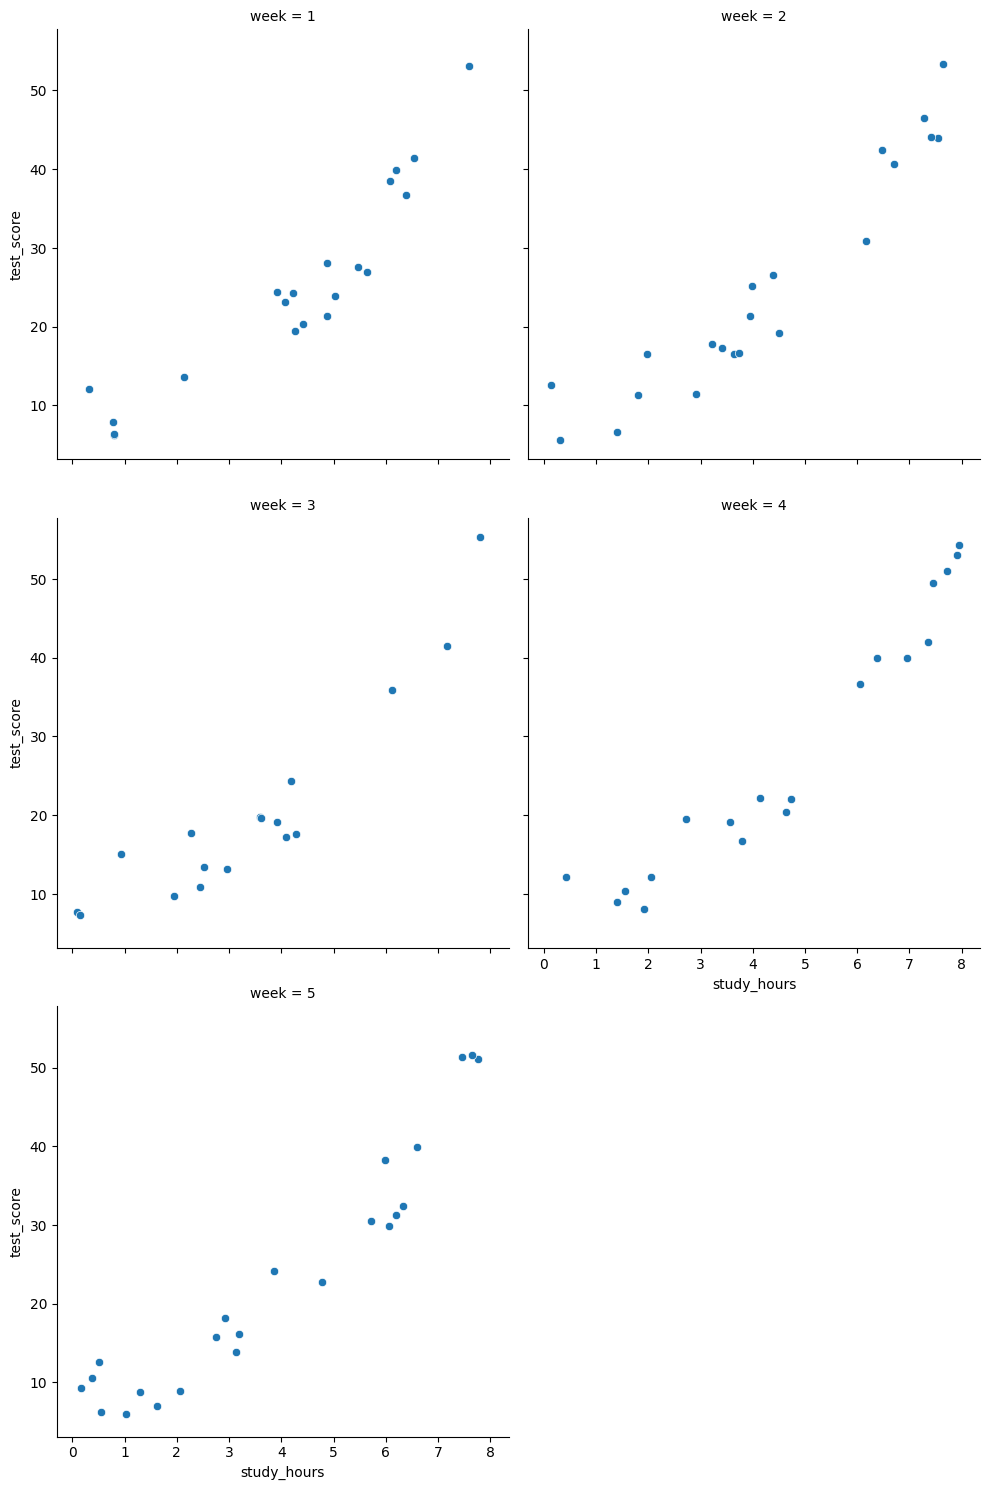

In [48]:
sns.relplot(kind="scatter", data=df, x="study_hours", y="test_score", col="week", col_wrap=2)  # col_wrap is used to wrap the columns into multiple rows. here we are wrapping the columns into 2 rows. so we will get 2 columns in each row. and the number of rows will be determined by the number of unique values in the "week" column.

# histogram

<Axes: xlabel='attendance_rate', ylabel='Count'>

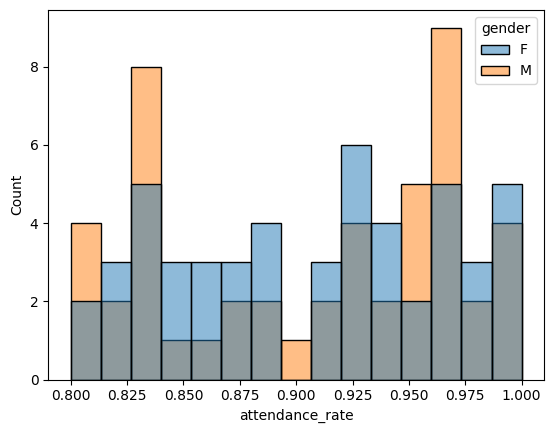

In [49]:
# axes level
sns.histplot(data=df, x="attendance_rate",hue="gender", bins=15,)

```python
Core difference (quick idea)
histplot() → single plot, more control
displot() → figure-level, multiple plots / faceting

<Axes: xlabel='attendance_rate', ylabel='Count'>

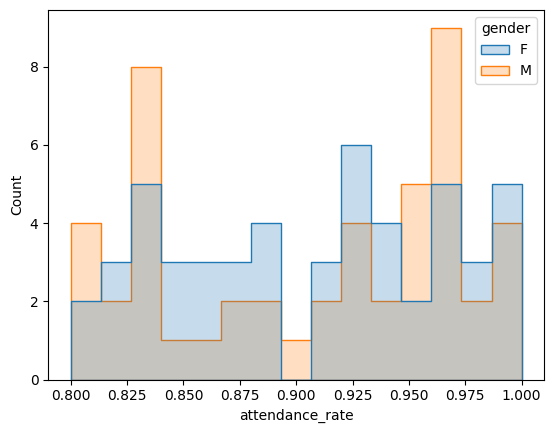

In [50]:
# axes level
sns.histplot(data=df, x="attendance_rate",hue="gender", bins=15, element='step')

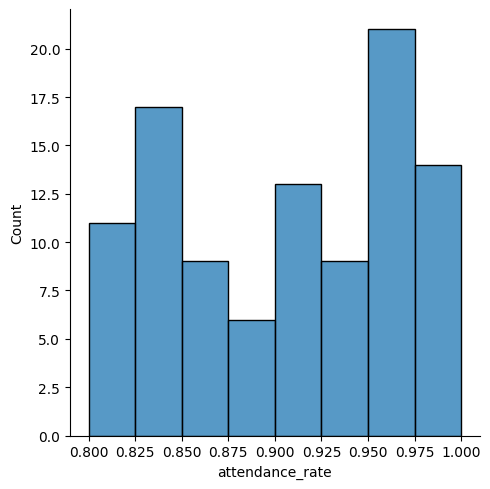

In [51]:
# figure level

sns.displot(kind="hist",data=df, x="attendance_rate")

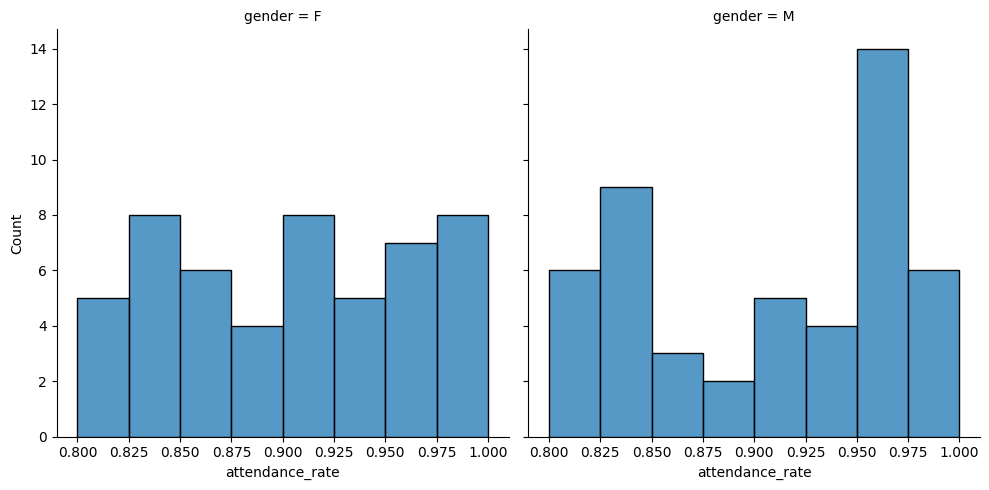

In [52]:
sns.displot(kind="hist",data=df, x="attendance_rate", col="gender")

# Kernal density estimation plot (KDE)

KDE plot (Kernel Density Estimation plot) হলো এমন একটি গ্রাফ যা ডেটার smooth distribution (মসৃণভাবে ছড়ানো) দেখায়—মানে histogram-এর মতোই, কিন্তু বার (bars) না দেখিয়ে একটা smooth curve দিয়ে বোঝায়।

In [53]:
tips_data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


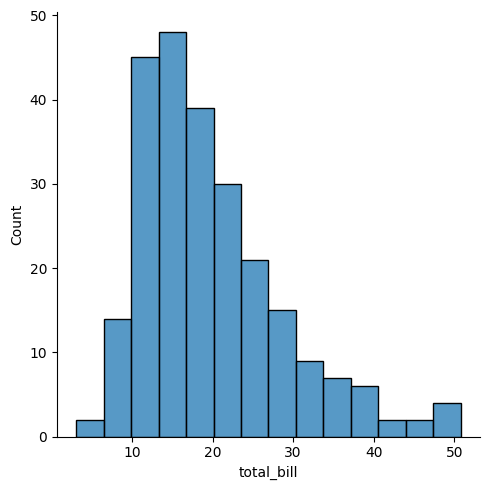

In [54]:
sns.displot(kind='hist', data=tips_data, x='total_bill')

<Axes: xlabel='total_bill', ylabel='Density'>

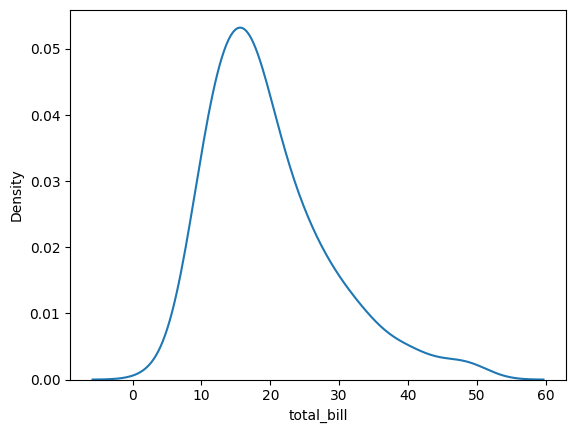

In [55]:
sns.kdeplot(data=tips_data, x='total_bill')

# Count plot and barplot

In [56]:
df.head()

,number_courses,time_study,Marks,student_id,class_level,subject,study_hours,test_score,week,attendance_rate,gender,hostel,Tshirt_size,class_name
0,3,4.508,19.202,1,10,Science,4.508,19.202,2,0.89,F,0,2,Sophomore
1,4,0.096,7.734,2,12,Math,0.096,7.734,3,0.98,M,0,3,Senior
2,4,3.133,13.811,3,11,Science,3.133,13.811,5,0.83,F,0,3,Junior
3,6,7.909,53.018,4,10,Science,7.909,53.018,4,0.92,F,1,4,Sophomore
4,8,7.811,55.299,5,11,English,7.811,55.299,3,0.80,M,1,4,Junior


<Axes: xlabel='gender', ylabel='count'>

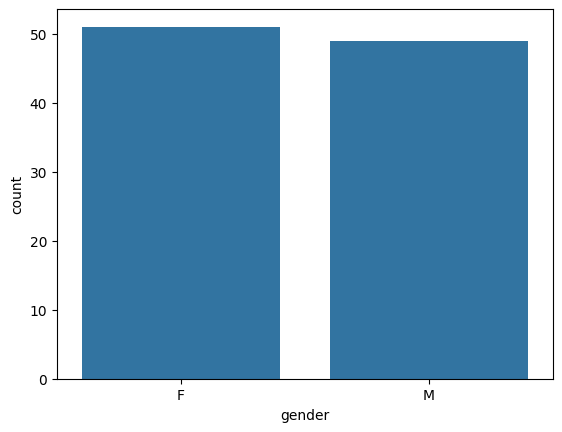

In [57]:
sns.countplot(data=df, x="gender")

<Axes: xlabel='gender', ylabel='Marks'>

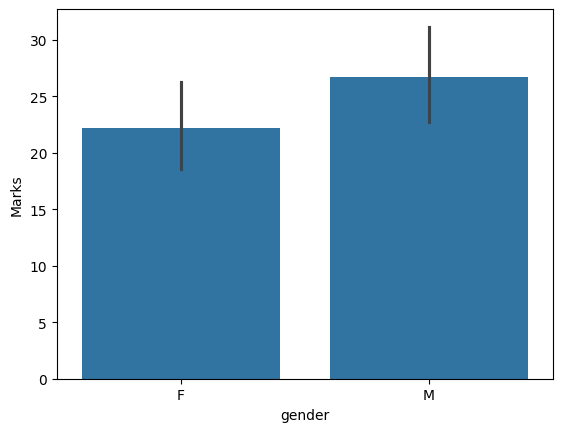

In [58]:
# barplot
# y axis a aggregate function thake

sns.barplot(data=df, x="gender", y="Marks")

# sns.barplot() এ defaultভাবে y-axis এ average (mean) দেখায়।
# so ekhane marks er average gulo gender wise dekhacche

<Axes: xlabel='gender', ylabel='Marks'>

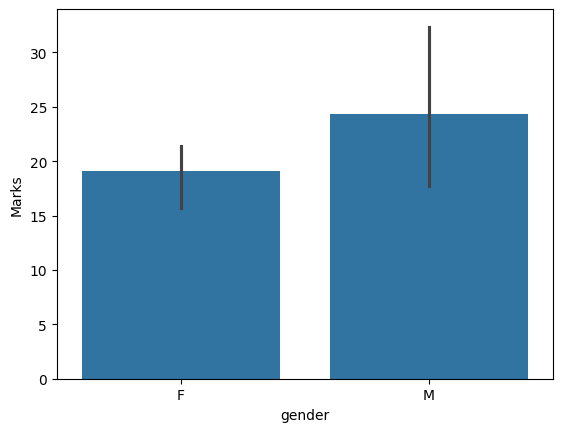

In [59]:
sns.barplot(data=df, x="gender", y="Marks", estimator=np.median) # estimator is used to change the aggregate function. here we are using median instead of mean. so ekhane marks

# Regression Plot

<Axes: xlabel='study_hours', ylabel='test_score'>

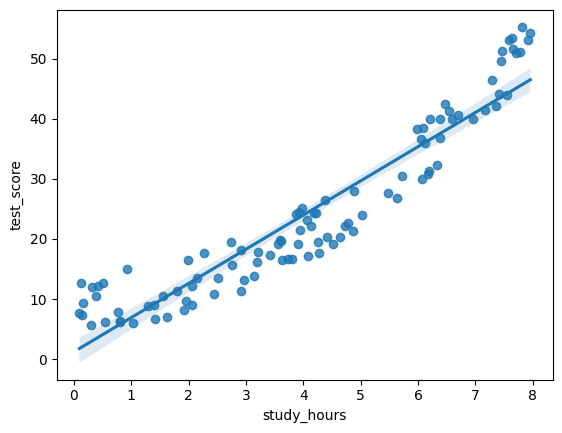

In [ ]:
# regression plot works like linear regression. it shows the relationship between two variables. it also shows the line of best fit. it is used to observe the correlation between two variables. it is used to predict the value of one variable based on the value of another variable.

# it works in axes level
sns.regplot(data =df, x="study_hours", y="test_score")

# sns.regplot() এ hue কাজ করে না।

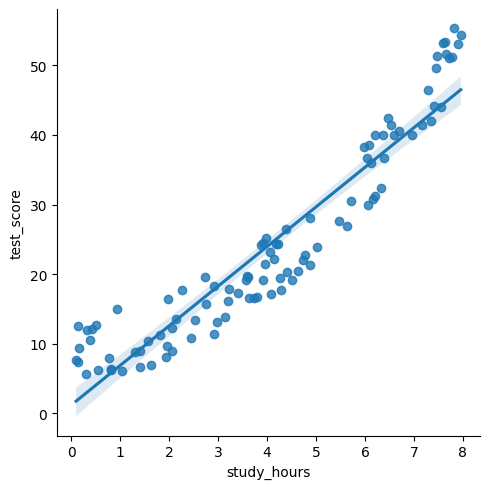

In [62]:
# to work with figure level

sns.lmplot(data=df, x="study_hours", y="test_score",)

# pairplot and joint plot

In [63]:
df = df[['Marks','study_hours','attendance_rate','gender']]
df.head()

,Marks,study_hours,attendance_rate,gender
0,19.202,4.508,0.89,F
1,7.734,0.096,0.98,M
2,13.811,3.133,0.83,F
3,53.018,7.909,0.92,F
4,55.299,7.811,0.80,M


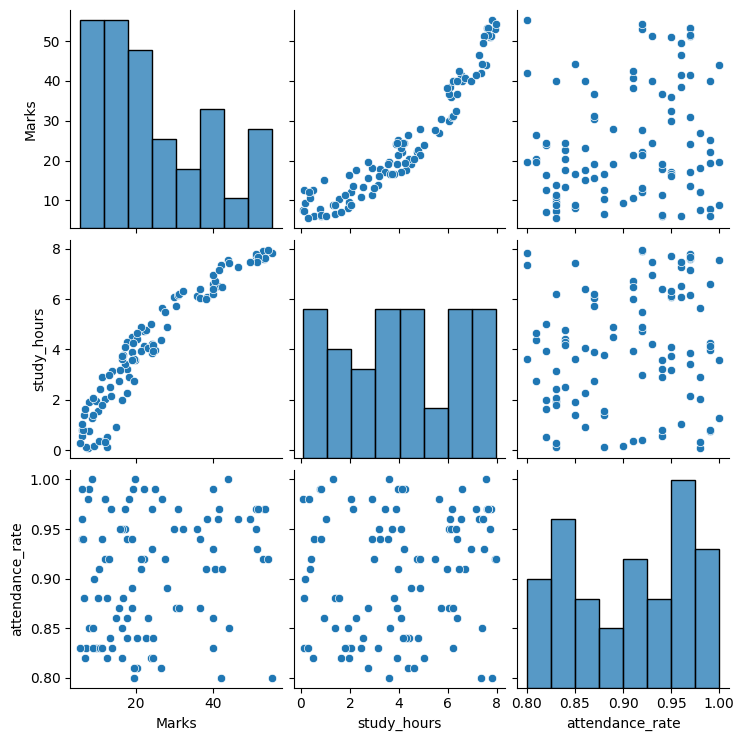

In [64]:
sns.pairplot(data=df)

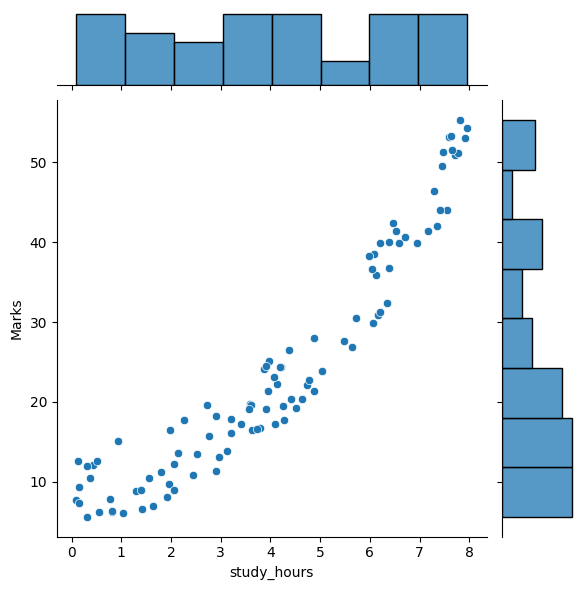

In [66]:
# joint plot

sns.jointplot(data=df, x="study_hours", y="Marks", kind="scatter")